Steel Materials Data Analysis
Exploring Composition, Mechanical Properties, and Yield Strength

Load the Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [ ]:
df = pd.read_excel("/steels.xlsx")

Initial Data Inspection

In [ ]:
df.shape

(3234, 31)

In [ ]:
df.columns

Index(['Entry', 'Name', 'Processing condition', 'Unnamed: 3',
       'Cluster Number (0 to 11)', 'Unnamed: 5', 'Al', 'Cu', 'Mn', 'N', 'Ni',
       'Ti', 'S', 'Fe', 'Zr', 'P', 'Si', 'V', 'Mo', 'Co', 'C', 'Nb', 'B', 'Cr',
       'Unnamed: 24', '(Ultimate) Tensile strength (MPa)',
       'Yield strength (MPa)', 'Ductility (%)', 'Unnamed: 28',
       'Cluster Number', 'Cluster label'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
Entry,0
Name,0
Processing condition,0
Unnamed: 3,3234
Cluster Number (0 to 11),0
Unnamed: 5,3234
Al,0
Cu,0
Mn,0
N,0


Data Cleaning

Four columns didn't contain any data. Removed for analysis.

In [ ]:
df = df.drop(columns=[
    "Unnamed: 3",
    "Unnamed: 5",
    "Unnamed: 24",
    "Unnamed: 28"
    ])

In [ ]:
df.columns

Index(['Entry', 'Name', 'Processing condition', 'Cluster Number (0 to 11)',
       'Al', 'Cu', 'Mn', 'N', 'Ni', 'Ti', 'S', 'Fe', 'Zr', 'P', 'Si', 'V',
       'Mo', 'Co', 'C', 'Nb', 'B', 'Cr', '(Ultimate) Tensile strength (MPa)',
       'Yield strength (MPa)', 'Ductility (%)', 'Cluster Number',
       'Cluster label'],
      dtype='object')

Verified that columns are now correct.

In [ ]:
df.duplicated().sum()

np.int64(0)

Checked that there are no duplicate rows.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3234 entries, 0 to 3233
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Entry                              3234 non-null   int64  
 1   Name                               3234 non-null   object 
 2   Processing condition               3234 non-null   object 
 3   Cluster Number (0 to 11)           3234 non-null   int64  
 4   Al                                 3234 non-null   float64
 5   Cu                                 3234 non-null   float64
 6   Mn                                 3234 non-null   float64
 7   N                                  3234 non-null   float64
 8   Ni                                 3234 non-null   float64
 9   Ti                                 3234 non-null   float64
 10  S                                  3234 non-null   float64
 11  Fe                                 3234 non-null   float

Yield Strength Distribution

In [ ]:
df["Yield strength (MPa)"].describe()

,Yield strength (MPa)
count,3234.000000
mean,648.439085
std,310.583216
min,159.000000
25%,415.000000
50%,596.000000
75%,841.000000
max,2395.000000


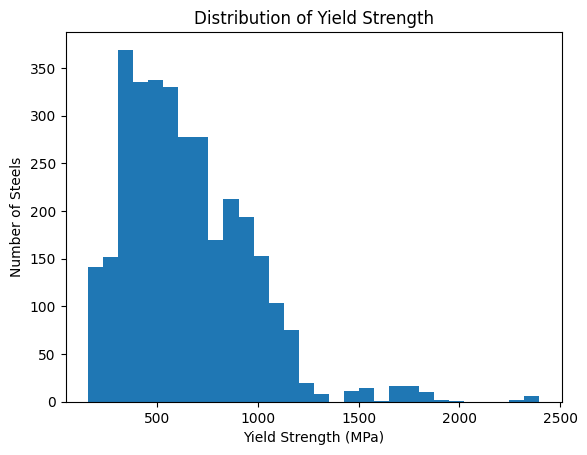

In [ ]:
df["Yield strength (MPa)"].plot(
    kind="hist",
    bins=30,
    title="Distribution of Yield Strength"
)

plt.xlabel("Yield Strength (MPa)")
plt.ylabel("Number of Steels")
plt.show()

Curious about isolated high strength observations.

In [ ]:
df[
    ["Name", "C", "Processing condition", "Yield strength (MPa)"]
].sort_values(
    by="Yield strength (MPa)",
    ascending=False
).head(10)

,Name,C,Processing condition,Yield strength (MPa)
1086,AISI Grade 18Ni (350) Maraging Steel,0.030,"Aged, At Rt, Tested Transverse, Sheet 6 mm Thick",2395
2079,AISI Grade 18Ni (350) Maraging Steel,0.030,"Aged, At Rt, Tested Transverse, Sheet 6 mm Thick",2395
2116,AISI Grade 18Ni (350) Maraging Steel,0.030,"Aged, At Rt, Tested Longitudinal, Round Bar 16 mm",2363
1079,AISI Grade 18Ni (350) Maraging Steel,0.030,"Aged, At Rt, Tested Longitudinal, Round Bar 16 mm",2363
1054,AISI Grade 18Ni (350) Maraging Steel,0.030,"Aged, At Rt, Tested Longitudinal, Round Bar 32 mm",2348
2136,AISI Grade 18Ni (350) Maraging Steel,0.030,"Aged, At Rt, Tested Longitudinal, Round Bar 32 mm",2348
2100,AISI Grade 18Ni (350) Maraging Steel,0.030,"Aged, At Rt, Tested Longitudinal, Round Bar 75 mm",2320
1045,AISI Grade 18Ni (350) Maraging Steel,0.030,"Aged, At Rt, Tested Longitudinal, Round Bar 75 mm",2320
1126,AISI Type S2 Tool Steel,0.475,"Austenitized 845C (1550F), Brine Quenched To 5...",2000
2154,AISI Grade 18Ni (250) Maraging Steel,0.030,"3.18 mm Thick Sheet, Solution Annealed At 815C...",1932


These values appear to be legitimate, confirmed accuracy through other sources online.

Ductility vs Yield Strength

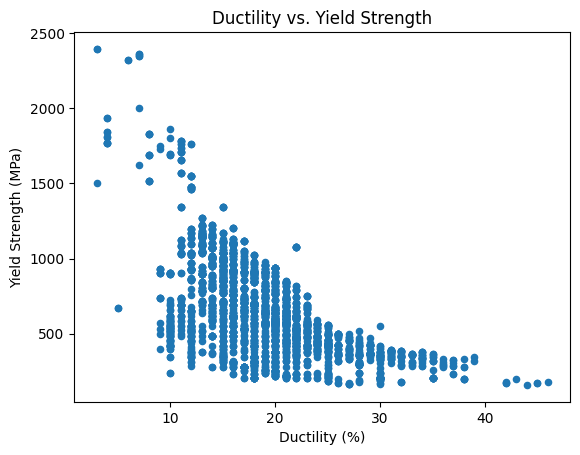

In [ ]:
df.plot(
    kind="scatter",
    x="Ductility (%)",
    y="Yield strength (MPa)",
    title="Ductility vs. Yield Strength",
)

plt.xlabel("Ductility (%)")
plt.ylabel("Yield Strength (MPa)")
plt.show()


In [ ]:
correlation = df["Ductility (%)"].corr(df["Yield strength (MPa)"])
print(correlation)

-0.6048687113729594


Ductility is moderately negatively correlated with yield strength in this dataset.

Carbon Content vs Yield Strength

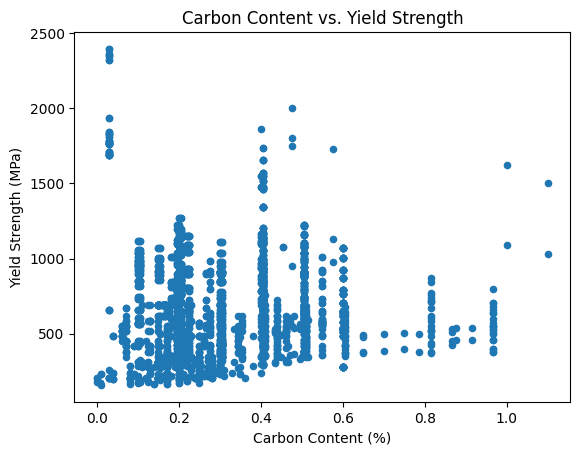

In [ ]:
df.plot(
    kind="scatter",
    x="C",
    y="Yield strength (MPa)",
    title="Carbon Content vs. Yield Strength"
)
plt.xlabel("Carbon Content (%)")
plt.ylabel("Yield Strength (MPa)")
plt.show()

In [ ]:
correlation = df["C"].corr(df["Yield strength (MPa)"])
print(correlation)

0.05466908347988547


Carbon content and yield strength have a very weak linear correlation. Substantial variation in yield strenth at similar carbon concentrations, suggesting that carbon content alone does not explain the variation in yield strength.

Composition Correlations

In [ ]:
composition_columns = [
    "Al", "Cu", "Mn", "N", "Ni", "Ti", "S", "Fe", "Zr", "P", "Si", "V", "Mo", "Co", "C", "Nb", "B", "Cr"
]

correlations = df[composition_columns].corrwith(
    df["Yield strength (MPa)"]
).sort_values(ascending=False)

correlations


,0
Co,0.445325
Mo,0.436222
Ni,0.410610
Ti,0.393454
Al,0.129166
Zr,0.097341
V,0.094015
C,0.054669
Si,0.011050
B,0.010935


Co, Mo, Ni, and Ti correlate (linearly and pairwise) with strength the most, but these correlations are only moderate.

Processing Condition Inspection

In [ ]:
df["Processing condition"].value_counts()

,count
Processing condition,
"Normalized, 100 mm (4 In.) Round",48
"Normalized, 50 mm (2 In.) Round",48
"Normalized, 13 mm (0.5 In.) Round",46
"Normalized, 25 mm (1 In.) Round",42
"Hot Rolled, 19-32 mm (0.75-1.25 In) Round",36
...,...
Austenitized At 785-815C (1450-1500F),1
3 To 5 In Premium Nitriding Steel,1
Up To 1.5 In Premium Nitriding Steel,1


Too many groups to run an analysis on. Maybe we can group them into broader categories?

In [ ]:
df["Processing condition"].value_counts().head(30)

,count
Processing condition,
"Normalized, 100 mm (4 In.) Round",48
"Normalized, 50 mm (2 In.) Round",48
"Normalized, 13 mm (0.5 In.) Round",46
"Normalized, 25 mm (1 In.) Round",42
"Hot Rolled, 19-32 mm (0.75-1.25 In) Round",36
"Annealed, 25 mm (1 In.) Round",34
Grade B,30
Grade A,29
Grade C,23


The processing condition column contains detailed text descriptions, not standard categories. Common entires include: normalized, annealed, hot rolled, cold drawn, and quenched/tempered. Also included are temperatures, dimensions, and grades.
Because they are descriptive information, they will not be used as a categorical variable in this analysis.

SQL Analysis

In [ ]:
conn = sqlite3.connect("steels.db")
df.to_sql("steels", conn, if_exists="replace", index=False)

3234

In [ ]:
query = """
SELECT *
FROM steels
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Entry,Name,Processing condition,Cluster Number (0 to 11),Al,Cu,Mn,N,Ni,Ti,...,Co,C,Nb,B,Cr,(Ultimate) Tensile strength (MPa),Yield strength (MPa),Ductility (%),Cluster Number,Cluster label
0,1,AISI 4023 Steel,"Normalized At 925C (1700F), Machined To 25 mm ...",0,0.0,0.0,0.8,0.0,0.0,0.0,...,0.0,0.225,0.0,0.0,0.0,745,440,21,0,Carburized – quenched (oil) – wear-resistant s...
1,2,AISI 4027 Steel,"Water Quenched 865C (1590F), 540C (1000F) Temp...",10,0.0,0.0,0.8,0.0,0.0,0.0,...,0.0,0.275,0.0,0.0,0.0,689,510,25,10,Quenched (water) & tempered – high-strength st...
2,3,AISI 4027 Steel,"Water Quenched 865C (1590F), 480C (900F) Tempe...",10,0.0,0.0,0.8,0.0,0.0,0.0,...,0.0,0.275,0.0,0.0,0.0,786,615,22,10,Quenched (water) & tempered – high-strength st...
3,4,AISI 4027 Steel,"Water Quenched 865C (1590F), 480C (900F) Tempe...",10,0.0,0.0,0.8,0.0,0.0,0.0,...,0.0,0.275,0.0,0.0,0.0,1035,917,16,10,Quenched (water) & tempered – high-strength st...
4,5,AISI 4027 Steel,"Water Quenched 865C (1590F), 595C (1100F) Temp...",10,0.0,0.0,0.8,0.0,0.0,0.0,...,0.0,0.275,0.0,0.0,0.0,717,550,24,10,Quenched (water) & tempered – high-strength st...


Data has been read successfuly.

Which steel grades have highest average yield strength, and how many observations do they have?

In [ ]:
query = """
SELECT
    Name,
    COUNT(*) AS sample_count,
    AVG("Yield strength (MPa)") AS avg_yield_strength
FROM steels
GROUP BY Name
ORDER BY avg_yield_strength DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,Name,sample_count,avg_yield_strength
0,AISI Grade 18Ni (350) Maraging Steel,8,2356.500000
1,ATI AllvacÂ® NickelvacÂ® 43-40 UNS G43400,1,1861.000000
2,AISI Type S1 Tool Steel,2,1775.000000
3,AISI Grade 18Ni (250) Maraging Steel,24,1687.833333
4,AISI Grade 18Ni (200) Maraging Steel,14,1588.571429
5,AISI Type W2 Tool Steel,2,1357.500000
6,AISI Type S5 Tool Steel,3,1278.333333
7,AISI Type W1 Tool Steel,2,1265.000000
8,AISI Type S2 Tool Steel,3,1166.666667
9,AISI 86B45 Steel,2,1080.000000


Although 18Ni (350) Maraging Steel tops the dataset in average yield, the lack of sufficient observations makes this a potential outlier. Which grades demonstrate high average yield backed by enough data points to ensure reliability?

In [ ]:
query = """
SELECT
    Name,
    COUNT(*) AS sample_count,
    AVG("Yield strength (MPa)") AS avg_yield_strength
FROM steels
GROUP BY Name
HAVING COUNT(*) >= 10
ORDER BY avg_yield_strength DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,Name,sample_count,avg_yield_strength
0,AISI Grade 18Ni (250) Maraging Steel,24,1687.833333
1,AISI Grade 18Ni (200) Maraging Steel,14,1588.571429
2,AISI E4340 H Steel,40,975.950000
3,AISI 4340 Steel,40,975.950000
4,AISI 4140 Steel,64,965.375000
5,AISI 4815H Steel,16,948.750000
6,AISI 4815 Steel,16,948.750000
7,AISI E4340 Steel,46,927.347826
8,AISI 8822H Steel,16,907.875000
9,AISI 8822 Steel,16,907.875000


After restricting analysis to steel grades with at least 10 observations, 18Ni (250) Maraging Steel has the highest average yield strength.

What percent of the dataset has a yield strength above 1000 MPa?

In [ ]:
query = """
SELECT
    COUNT(*) AS high_strength_count,
    ROUND(
        100.0 * COUNT(*) / (SELECT COUNT(*) FROM steels),
        2
    ) AS percentage_of_dataset
FROM steels
WHERE "Yield strength (MPa)" > 1000;
"""

result = pd.read_sql_query(query, conn)
result

,high_strength_count,percentage_of_dataset
0,390,12.06


390 steels, or 12.06% of the dataset have a yield strength above 1000 MPa.

Which steel grades have the most observations?

In [ ]:
query = """
SELECT
    Name,
    COUNT(*) AS sample_count
FROM steels
GROUP BY Name
ORDER BY sample_count DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,Name,sample_count
0,AISI 8620H Steel,72
1,AISI 8620 Steel,72
2,ASTM A514 Steel,70
3,AISI 4140H Steel,70
4,AISI 4140 Steel,64
5,AISI E9310H Steel,58
6,AISI E9310 Steel,58
7,AISI 4820H Steel,58
8,AISI 4820 Steel,58
9,AISI 4320 Steel,58


The most frequently represented steel grades have between 58 and 72 observations in the dataset. This variation in sample size supports using a minimum observation threshold when comparing properties across steel grades.

Key Findings

- Carbon content showed a very weak linear correlation with yield strength (r ≈ 0.055), indicating that carbon content alone does not explain much of the variation in yield strength in this dataset.
- Yield strength and ductility showed a moderate negative correlation (r ≈ -0.605), with higher-strength steels generally showing lower ductility.
- The yield strength distribution was concentrated below approximately 1,250 MPa, with a small number of observations above 2,000 MPa. These high-strength observations were retained because they appeared to represent legitimate steel grades rather than obvious data errors.
- Among steel grades with at least 10 observations, 18Ni (250) and 18Ni (200) Maraging Steels had the highest average observed yield strengths.
- 390 observations, or 12.06% of the dataset, had yield strengths above 1,000 MPa.
- The dataset contains substantially different numbers of observations for different steel grades, which was considered when comparing group averages.

Conclusion

This project used Python, pandas, matplotlib, SQLite, and SQL to explore relationships between steel composition and mechanical properties in a dataset of 3,234 observations. The analysis showed that carbon content alone had little linear association with yield strength, while yield strength and ductility exhibited a stronger negative relationship. SQL analysis provided additional insight into the distribution of observations and average yield strength across steel grades.

The results demonstrate how data cleaning, exploratory analysis, visualization, and SQL can be combined to investigate materials science data.